In [30]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV

In [31]:
# Step 1: Load preprocessed data
X_train = pd.read_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\X_train.csv')
X_test = pd.read_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\X_test.csv')
y_train = pd.read_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\y_train.csv')
y_test = pd.read_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\y_test.csv')

In [32]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()


In [33]:
# ============================
# Step 2: Define Models & Grids
# ============================
param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    },
    "Decision Tree": {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    }
}


base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [34]:
# ============================
# Step 3: Hyperparameter Tuning + Evaluation
# ============================
results = []
for name, model in base_models.items():
    print(f"\n🔍 Tuning {name} ...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    print(f"✅ Best Params for {name}: {grid.best_params_}")

    # Evaluate model
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n📊 {name} Results:")
    print(classification_report(y_test, y_pred))

    # Save best model
    with open(f'../models/{name.replace(" ", "_").lower()}_best.pkl', 'wb') as f:
        pickle.dump(best_model, f)


🔍 Tuning Logistic Regression ...
✅ Best Params for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

📊 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.86      0.74      0.80        82
           1       0.81      0.90      0.86       102

    accuracy                           0.83       184
   macro avg       0.84      0.82      0.83       184
weighted avg       0.83      0.83      0.83       184


🔍 Tuning Random Forest ...
✅ Best Params for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

📊 Random Forest Results:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        82
           1       0.82      0.87      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184


🔍 Tuning KNN ...
✅ Best Params for KNN: {'n_neighbors': 9

In [35]:
# ============================
# Step 4: Compare Models
# ============================
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.sort_values(by='Accuracy', ascending=False))

# Save results to CSV
results_df.to_csv('../models/model_comparison.csv', index=False)


=== Model Comparison ===
                 Model  Accuracy  Precision    Recall  F1 Score
2                  KNN  0.836957   0.827273  0.892157  0.858491
0  Logistic Regression  0.831522   0.814159  0.901961  0.855814
3                  SVM  0.831522   0.838095  0.862745  0.850242
5    Gradient Boosting  0.826087   0.830189  0.862745  0.846154
1        Random Forest  0.820652   0.816514  0.872549  0.843602
4        Decision Tree  0.809783   0.819048  0.843137  0.830918


<Figure size 1000x600 with 0 Axes>

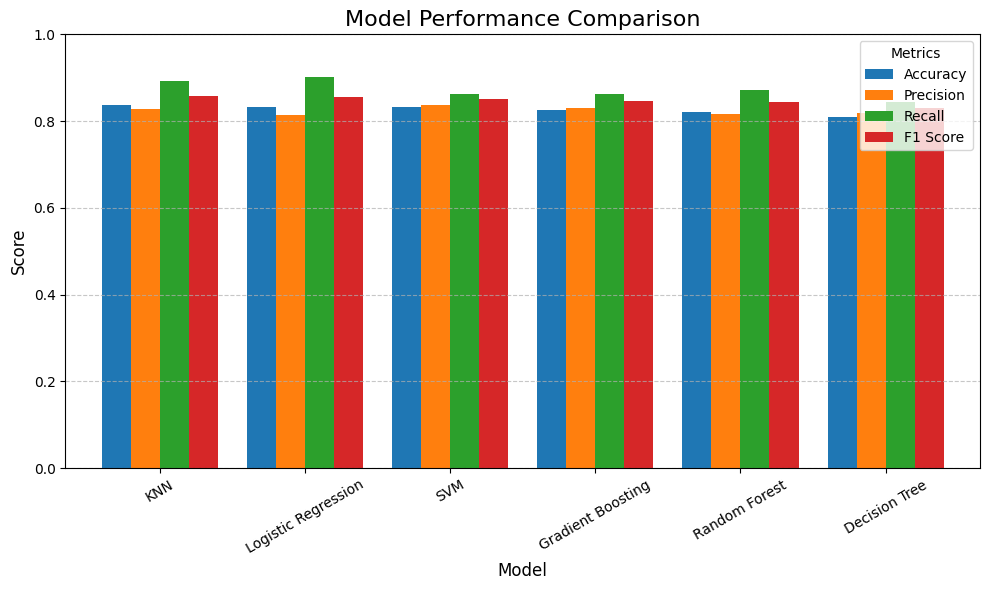

In [36]:
import matplotlib.pyplot as plt

# Convert results list to DataFrame
results_df = pd.DataFrame(results)

# Sort models by accuracy (highest first)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Set figure size
plt.figure(figsize=(10, 6))

# Plot all four metrics as grouped bars
results_df.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar',
    figsize=(10, 6),
    width=0.8
)

# Title and labels
plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Metrics')
plt.ylim(0, 1)  # Since scores are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [38]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Select the best model based on Accuracy (you can switch to 'F1 Score' if needed)
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = base_models[best_model_name]

print(f"\n✅ Best Model Selected: {best_model_name}")
print(results_df.sort_values(by='Accuracy', ascending=False))

# Refit best model on full training data (recommended)
best_model.fit(X_train, y_train)

# Save the best model to a pickle file
import pickle
with open('../models/best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f"\n🎉 Best model '{best_model_name}' saved successfully as 'best_model.pkl'!")



✅ Best Model Selected: KNN
                 Model  Accuracy  Precision    Recall  F1 Score
2                  KNN  0.836957   0.827273  0.892157  0.858491
0  Logistic Regression  0.831522   0.814159  0.901961  0.855814
3                  SVM  0.831522   0.838095  0.862745  0.850242
5    Gradient Boosting  0.826087   0.830189  0.862745  0.846154
1        Random Forest  0.820652   0.816514  0.872549  0.843602
4        Decision Tree  0.809783   0.819048  0.843137  0.830918

🎉 Best model 'KNN' saved successfully as 'best_model.pkl'!
